<div style="box-sizing:border-box; height:11in; border:5px solid black; border-radius:6px; display:flex; flex-direction:column; justify-content:center; padding:48px;">
<div style="text-align:center;">

# **Prompt Engineering in Practice: Evaluating a Popular LLM, Across Differing Task Types**
## **Author: Tim Hollis**
## **Bellevue University**
## **Course: DSC670 - Advanced Uses of Generative AI**
## **Professor Neugebauer**
## **Date:** June 16, 2026

</div>
</div>

<div style="padding-top:0.75in;">

## Prompt Engineering in Practice: Evaluating a Popular LLM, Across Differing Task Types

<div style="text-indent:0.5in;">

For this exercise I designed and tested prompts for three tasks in Microsoft Copilot: text generation, sentiment analysis, and simple arithmetic. The results show a clear pattern. Prompt engineering produced reliable, high-quality output on the two language-based tasks, but it could not correct a basic computational error on the math task.

For Problem 1, I asked Copilot to write a 200-word, first-person, active-voice summary of prompt engineering and to cite any sources in APA 7 format. The output followed every constraint. It stayed close to the target length, held first-person active voice throughout, and supplied a properly formatted citation and reference for White et al. (2023). This result suggests that explicit constraints, naming the word count, the voice, and the citation requirement, give the model concrete targets it can satisfy. The clearer the specification, the closer the alignment between intent and output.

Problem 2 tested whether the model could read sentiment that contradicts the literal words. The input, "That was FINE example of teaching an intelligent automation class. :-/", praises on the surface while signaling the opposite. Copilot correctly classified the overall sentiment as negative and identified sarcasm, disappointment, frustration, and dismissiveness. More importantly, it justified each label with the right cues: the capitalized FINE, the clipped phrasing, and the :-/ emoticon. Detecting non-literal sentiment is difficult because it depends on tone rather than vocabulary, so this was a strong result that showed the model weighing punctuation and formatting as meaning.

Problem 3 produced the most revealing outcome. I gave a tightly constrained prompt asking only for the sum of 2,292.32 and 4494 1/3 as a single fraction. Copilot returned 204859/45, which equals roughly 4,552. The correct sum is 508999/75, or about 6,786.65. The model failed despite a clear prompt. This matters because it exposes the limits of prompt engineering. A good prompt cannot repair a weakness that lives in how the model computes. Dziri et al. (2023) found that transformer-based models get close to 45% of three-digit multiplication problems wrong, which points to a structural difficulty with multi-step exact arithmetic rather than a one-off slip.

Taken together, the three results draw a useful line. Prompt engineering reliably shaped the linguistic tasks, where the work is essentially about language. It did not rescue the arithmetic task, where the work is exact calculation. The practical lesson is to pair language models with external tools, such as a calculator or code interpreter, whenever a task demands precise computation, and to verify numeric output rather than trust it.

</div>

</div>,

<div style="page-break-before: always;"></div>

<div style="padding-top:0.75in;">

## Problem 4: Invoice Extraction with the OpenAI API

For Problem 4 I use the OpenAI API to read a business invoice and turn it into structured JSON. I split the work into two API calls so I can judge transcription and structuring separately, and I check the output back against the source document.

### **Initial Setup**

In [1]:
# Loading libraries
import os
import json
from getpass import getpass
from openai import OpenAI

# Prompting for the key at runtime with a masked input
api_key = getpass('Enter your OpenAI API key: ')
client = OpenAI(api_key=api_key)

# Global configuration
PDF_PATH = 'Invoice.pdf'
EXTRACTION_MODEL = 'gpt-4o'
JSON_MODEL = 'gpt-4o'

print('📦 Libraries loaded and OpenAI client ready')
print(f'📄 Target document: {PDF_PATH}')
print(f'🤖 Using model: {EXTRACTION_MODEL}')

Enter your OpenAI API key:  ········


📦 Libraries loaded and OpenAI client ready
📄 Target document: Invoice.pdf
🤖 Using model: gpt-4o


<div style="page-break-before: always;"></div>

## Step 1: Extract the Invoice Text with the OpenAI API

The assignment calls for the OpenAI API to do the extraction, so instead of parsing the PDF with a local library I hand the file directly to a vision-capable model and ask it to transcribe what it sees. I deliberately split the task into two API calls. This first one only reads the document and returns raw text; a later call handles the conversion to JSON. Keeping transcription separate from structuring lets me judge each step on its own, which matters because misreading the document and mis-organizing it are very different failures, and I want to know which one happened if something looks off.

In [2]:
# Upload the invoice to the OpenAI Files endpoint
uploaded = client.files.create(
    file=open(PDF_PATH, 'rb'),
    purpose='user_data'
)
print(f'📤 Uploaded {PDF_PATH} (file id: {uploaded.id})')

# Ask a vision-capable model to read the document and return its raw text
extraction_prompt = (
    'You are reading a business invoice. '
    'Transcribe every piece of text exactly as it appears, including labels, '
    'line items, dollar amounts, percentages, and footer notes. '
    'Preserve the values verbatim and do not summarize, reformat, or fill in blanks.'
)

extraction_response = client.responses.create(
    model=EXTRACTION_MODEL,
    input=[
        {
            'role': 'user',
            'content': [
                {'type': 'input_file', 'file_id': uploaded.id},
                {'type': 'input_text', 'text': extraction_prompt}
            ]
        }
    ]
)

invoice_text = extraction_response.output_text
print('📝 Extracted invoice text:\n')
print(invoice_text)

📤 Uploaded Invoice.pdf (file id: file-RGgNNig2uWbnrmKvosZn2z)
📝 Extracted invoice text:

<PARSED TEXT FOR PAGE: 1 / 1>

321 Avenue A Date: 6/28/2024  
Portland, OR 12345 Invoice # 1111  
Phone: (206) 555-1163 For PO # 123456  
Fax: (206) 555-1164  
someone@websitegoeshere.com  
Quantity Description Unit price Amount Discount applied  
1 Item Number 1 $ 2.00 2.00 $  
1 Item Number 2 $ 2.00 2.00 $  
1 Item Number 3 $ 2.00 2.00 $  
$ -  
$ -  
$ -  
$ -  
$ -  
$ -  
$ -  
$ -  
Subtotal 6.00 $  
Credit $ 1,000.00  
Tax 9.80%  
Additional discount 12%  
Balance due (994.20) $  
Company Name  
INVOICE  
If you have any questions concerning this invoice, contact  
<Name> at <phone or email>.  
Make all checks payable to <Company name>.  
Thank you for your business!  
Bill To:  
Natasha Jones  
Central Beauty  
123 Main St.  
% discount 10%  
Manhattan, NY 98765  
(321) 555-1234  
Items over this amount qualify for an additional discount $100


<div style="page-break-before: always;"></div>

## Step 2: Convert the Extracted Text to Structured JSON

The raw transcription is complete but disordered, so this second call asks the model to reorganize it into a clean JSON object with named sections. I gave it specific instructions for the judgment calls this invoice forces: keep the placeholder fields exactly as written instead of guessing, drop the empty dash-only rows so they do not pollute the line items, and represent the balance due as a negative number since the document presents it in parentheses. I am curious whether the model honors all three, because each one is a small test of whether it reorganizes faithfully or quietly "tidies up" the data in ways I did not request.

In [3]:
# Convert the extracted text into structured JSON with a second API call
json_prompt = (
    'Convert the following invoice text into a single structured JSON object. '
    'Use these top-level keys: seller, invoice_metadata, bill_to, line_items, totals, and notes. '
    'List each real line item as an object with quantity, description, unit_price, and amount, '
    'and ignore the empty placeholder rows that only contain a dash. '
    'Format every monetary amount as a string with a dollar sign and two decimal places, '
    'exactly as it appears on the invoice (for example, "$2.00" and "$1,000.00"). '
    'Show the balance due as a negative currency string because the invoice presents it in '
    'parentheses (for example, "-$994.20"). '
    'Keep placeholder values such as <Name> or <Company name> exactly as written rather than guessing. '
    'Capture percentage fields like tax and the discounts as their literal values. '
    'Return only valid JSON with no surrounding text or code fences.\n\n'
    f'Invoice text:\n{invoice_text}'
)

json_response = client.responses.create(
    model=JSON_MODEL,
    input=json_prompt
)

# Removing code fences if the model wrapped the JSON in them, then parsing
raw_json = json_response.output_text.strip()
if raw_json.startswith('```'):
    raw_json = raw_json.split('```')[1]
    raw_json = raw_json.removeprefix('json').strip()

structured = json.loads(raw_json)
print('🧾 Structured JSON output:\n')
print(json.dumps(structured, indent=2))

🧾 Structured JSON output:

{
  "seller": {
    "name": "Company Name",
    "address": "321 Avenue A, Portland, OR 12345",
    "phone": "(206) 555-1163",
    "fax": "(206) 555-1164",
    "email": "someone@websitegoeshere.com"
  },
  "invoice_metadata": {
    "date": "6/28/2024",
    "invoice_number": "1111",
    "po_number": "123456"
  },
  "bill_to": {
    "name": "Natasha Jones",
    "company": "Central Beauty",
    "address": "123 Main St., Manhattan, NY 98765",
    "phone": "(321) 555-1234",
    "discount": "10%"
  },
  "line_items": [
    {
      "quantity": "1",
      "description": "Item Number 1",
      "unit_price": "$2.00",
      "amount": "$2.00"
    },
    {
      "quantity": "1",
      "description": "Item Number 2",
      "unit_price": "$2.00",
      "amount": "$2.00"
    },
    {
      "quantity": "1",
      "description": "Item Number 3",
      "unit_price": "$2.00",
      "amount": "$2.00"
    }
  ],
  "totals": {
    "subtotal": "$6.00",
    "credit": "$1,000.00",
    

<div style="page-break-before: always;"></div>

<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## Summary

Using the OpenAI API, I extracted the invoice text with one call and converted it into structured JSON with a second call. The pipeline worked well: faithful transcription, clean organization, and correct handling of the trickiest fields. The value of the exercise was less in proving the API can do this and more in seeing where it makes unannounced judgment calls, which is exactly where human review has to stay in the loop.

---

## Reflection

Splitting the work into two calls paid off because it lets me separate what the model read from what the model decided. The extraction step was essentially perfect. It transcribed every value verbatim, left placeholder fields like &lt;Name&gt; and &lt;Company name&gt; untouched, kept the empty rows, and preserved the balance due in its original parenthetical form. Anything I question below comes from the structuring step, not from a misread page.

The structuring step got the hard formatting right. The dollar amounts came back as clean currency strings such as `"$2.00"` and `"$1,000.00"`, the percentages stayed as written, and the balance due is `"-$994.20"`, which shows the model read the parentheses as a negative rather than as decoration. That point matters most because the `$1,000` credit against a `$6.00` subtotal means the customer is actually owed money, and the sign survived. With every formatted value stored as a string, the typing is also consistent, though it would need to be parsed before any math.

The more revealing results are the things the model decided on its own. Two real fields from the invoice at times when running the notebook, don't make it into the structured JSON call: the `"% discount 10%"` line and the note that items over `$100` qualify for an additional discount, when I originally wrote this reflection, neither appeared, but after running one final time before submission, the line about the discount qualifier, appears. Both appear in the raw transcription, so the model did not fail to read them; at times, it seemingly chooses not to carry them forward. Nothing flagged the omission. The JSON looks complete, and only a line-by-line check against the source reveals the gap. The model also made structural calls I did not specify, collapsing the address fields into single strings and merging the three footer lines into one note instead of a list. Those are reasonable readings, but they are readings, not the only correct answer.

All of this lines up with the math problem from earlier in the assignment. The model is fast, it reads well, and it organizes confidently, but it makes silent choices when the input is ambiguous, and it can quietly drop real information without saying so. For a financial document, especially, that is the whole argument for keeping a human in the loop. "Looks right" and "is right" are not the same thing, and the only way to tell them apart here was to read the JSON back against the invoice.

</div>

<div style="page-break-before: always;"></div>

## References

<div style="padding-left: 36px; text-indent: -36px; margin-bottom: 12px;">
Bellevue University. (2024). <em>DSC 670 exercise invoice</em> [PDF]. https://content.bellevue.edu/cst/dsc/670/dsc-670-exercise-invoice.pdf
</div>

<div style="padding-left: 36px; text-indent: -36px; margin-bottom: 12px;">
Dziri, N., Lu, X., Sclar, M., Li, X. L., Jiang, L., Lin, B. Y., West, P., Bhagavatula, C., Le Bras, R., Hwang, J. D., Sanyal, S., Welleck, S., Ren, X., Ettinger, A., Harchaoui, Z., &amp; Choi, Y. (2023). <em>Faith and fate: Limits of transformers on compositionality.</em> arXiv. https://doi.org/10.48550/arXiv.2305.18654
</div>

<div style="padding-left: 36px; text-indent: -36px; margin-bottom: 12px;">
White, J., Fu, Q., Hays, S., Sandborn, P., Olea, C., Gilbert, S., &amp; Schmidt, D. C. (2023). <em>A prompt pattern catalog to enhance prompt engineering with ChatGPT.</em> arXiv. https://doi.org/10.48550/arXiv.2302.11382
</div>

## Appendix: Copilot Prompts and Responses

#### Problem #1 - Text Generation

Type: text generation<br>
Output: A 200-word summary of prompt engineering<br>
Voice: first person active voice<br>
Other: APA-compliant references if applicable.

**Problem 1 Prompt:**

<div style="background:#f4f6fb; border-left:4px solid #4169E1; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px;">
Write a 200-word summary explaining what prompt engineering is. Write it in first person using active voice (for example, "I craft prompts to..."). Keep it to roughly 200 words. If you reference any external sources, cite them in APA 7 format and include a reference entry.
</div>

**Copilot's response:**

<div style="background:#f7f7f7; border-left:4px solid #4B0082; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px;">
<p>I see prompt engineering as the craft of shaping language so an AI system understands exactly what I want. When I engineer a prompt, I actively decide what context to include, what constraints to set, and what outcome I'm aiming for. I guide the model by choosing clear instructions, supplying examples, or breaking a complex task into smaller steps. I'm not just typing a request - I'm designing an interaction that steers the model's reasoning.</p>
<p>I also pay attention to tone, structure, and specificity. If I want a creative response, I frame the prompt loosely; if I need precision, I tighten the wording and define boundaries. I test variations, observe how the model responds, and refine the prompt until the output aligns with my intent. In that sense, prompt engineering feels iterative and hands-on, like tuning a system through language.</p>
<p>At its core, prompt engineering helps me collaborate more effectively with AI. By understanding how models interpret instructions, I can craft prompts that reduce ambiguity, improve accuracy, and unlock more sophisticated results. Researchers describe this as a way of "guiding model behavior through carefully designed inputs," which captures the essence of what I do when I engineer prompts (White et al., 2023).</p>
<p style="margin-bottom:0;"><strong>Reference:</strong> White, J., Fu, Q., Hays, S., Sandborn, P., Olea, C., Gilbert, S., &amp; Schmidt, D. C. (2023). A prompt pattern catalog to enhance prompt engineering with ChatGPT. arXiv. https://doi.org/10.48550/arXiv.2302.11382</p>
</div>

#### Problem #2 - Sentiment Analysis

Type: sentiment analysis<br>
Input: That was FINE example of teaching an intelligent automation class. :-/<br>
Output: the emotions the text conveys

**Problem 2 Prompt:**

<div style="background:#f4f6fb; border-left:4px solid #4169E1; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px;">
Perform a sentiment and emotion analysis on the following text. Identify the emotions it conveys and explain the cues that signal them, including tone, punctuation, and any sarcasm. Text: "That was FINE example of teaching an intelligent automation class. :-/"
</div>

**Copilot's Response:**

<div style="background:#f7f7f7; border-left:4px solid #4B0082; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px;">
<p>Here's the emotional read on that sentence - and it's definitely not as "fine" as the wording pretends.</p>
<p><strong><em>Overall Sentiment</em></strong></p>
<ul>
<li>The sentiment is negative. Even though the word FINE appears positive on the surface, the way it's written signals frustration or disappointment.</li>
</ul>
<p><strong><em>Emotions Conveyed</em></strong></p>
<ul>
<li>Sarcasm - The capitalized FINE flips the meaning from praise to criticism. It reads like the speaker is saying the opposite of what they actually feel.</li>
<li>Disappointment - The tone suggests the class did not meet expectations.</li>
<li>Frustration or annoyance - The closing emoticon ":-/" is a classic cue for displeasure, skepticism, or mild irritation.</li>
<li>Dismissiveness - The phrasing "That was FINE example..." feels intentionally clipped, as if the speaker is holding back stronger criticism.</li>
</ul>
<p><strong><em>Cues That Signal These Emotions</em></strong></p>
<ul>
<li>Capitalization: Writing FINE in all caps is a common way to emphasize sarcasm or irritation.</li>
<li>Tone: The sentence structure is short and blunt, which often signals annoyance.</li>
<li>Emoticon ":-/": This face conveys a sideways, unimpressed expression - a nonverbal cue of dissatisfaction.</li>
<li style="margin-bottom:0;">Word choice: "That was FINE example..." lacks warmth or specificity, which makes the praise feel insincere.</li>
</ul>
</div>

#### Problem #3 - Simple Math

Type: text generation and reasoning<br>
Output: the sum of 2,292.32 and 4494 1/3<br>
Rules: return only the result and make the result a fraction

**Prompt for problem 3:**

<div style="background:#f4f6fb; border-left:4px solid #4169E1; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px;">
Calculate the sum of 2,292.32 and 4494 1/3. Return only the final result, expressed as a single fraction. Do not show any steps or explanation.
</div>

**Copilot's Response:**

<div style="background:#f7f7f7; border-left:4px solid #4B0082; padding:10px 14px; margin:6px 0 16px 0; border-radius:4px; text-align:center;">
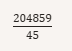
</div>

<div style='border: 5px solid black; padding: 20px; border-radius: 6px;'>
    
# Reflection for Week 2

## General Reflection
This week in DSC670 pushed me to move beyond “using” an LLM and into really testing its boundaries. Designing prompts for text generation, sentiment analysis, and arithmetic made it clear that prompt engineering is powerful, but not magic. The model handled language-centric tasks impressively well when I gave clear constraints, like word count, voice, and citation style. At the same time, the math problem and the invoice extraction exercise highlighted where LLMs still need guardrails, external tools, and human review. Overall, the week felt like a shift from curiosity about generative AI to a more grounded understanding of where it shines and where it quietly fails.

## Straightforward Aspects
- Crafting the prompt for the 200-word, first-person summary of prompt engineering was intuitive, and the model followed the constraints closely.
- The sentiment analysis task felt natural, and the model’s ability to pick up sarcasm and tone matched my expectations.
- Structuring the invoice JSON prompt was clear once I decided on the top-level keys and formatting rules.
- Writing the formal paper summarizing Problems 1–3 flowed well because the results lined up neatly with the idea that language tasks are the model’s strength.

## Challenging Aspects
- The arithmetic task exposed how unreliable LLMs can be with exact computation, even when the prompt is precise, which was both surprising and a little unsettling.
- Evaluating the invoice extraction required careful comparison between the raw text and the JSON to catch subtle omissions and silent judgment calls.
- Balancing trust and skepticism was tricky: the outputs often “looked right,” but verifying them showed where information was dropped or reinterpreted.
- Writing commentary in the notebook that went beyond code explanation forced me to slow down and articulate what the results really implied about LLM limits and responsible use.

## **Added Benefit:**

**As a small added benefit, formatting the paper in Markdown helped me refine the HTML techniques I already use each week. It was not a major aha moment, but it did give me a bit of new understanding in both indentation control and adding a shaded highlight inside a Markdown cell.**

</div>